In [1]:
from pyspark.sql import SparkSession

spark = (
        SparkSession.builder
        .appName("fintek_analytics")
        .master("spark://spark-master:7077")

        .config("spark.executor.memory", "2g")
        .config("spark.driver.memory", "1g")
        .config("spark.executor.cores", 2)
        .config("spark.sql.shuffle.partitions", 10)

        .config("spark.driver.host", "fintek-jupyter")
        .config("spark.driver.bindAddress", "0.0.0.0")

        .config("spark.jars.packages", "org.postgresql:postgresql:42.7.3")

        .getOrCreate()
    )

:: loading settings :: url = jar:file:/opt/conda/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/rapids/.ivy2.5.2/cache
The jars for the packages stored in: /home/rapids/.ivy2.5.2/jars
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-0a43ef92-f782-4934-85a4-2899c6acf7f3;1.0
	confs: [default]
	found org.postgresql#postgresql;42.7.3 in central
	found org.checkerframework#checker-qual;3.42.0 in central
:: resolution report :: resolve 79ms :: artifacts dl 3ms
	:: modules in use:
	org.checkerframework#checker-qual;3.42.0 from central in [default]
	org.postgresql#postgresql;42.7.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------

In [2]:
jdbc_url = "jdbc:postgresql://fintek-postgres:5432/fintek_db"

properties = {
    "user": "finance",
    "password": "finance123",
    "driver": "org.postgresql.Driver"
}

try:
    print("Veriler veritabanından okunuyor...")
    
    sql_returns = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            r.return_time,
            r.log_return,
            a.asset_type
        FROM returns r
        JOIN assets a
            ON r.asset_id = a.asset_id
        WHERE r.return_time >= '2020-01-01'
    ) AS index_returns
    """,
    properties=properties
)
    print("\n--- Returns ---")
    sql_returns.show(5)

except Exception as e:
    print(f"Veritabanına bağlanırken bir hata oluştu: {e}")

Veriler veritabanından okunuyor...

--- Returns ---


[Stage 0:>                                                          (0 + 1) / 1]

+------+-----------+--------------------+----------+
|ticker|return_time|          log_return|asset_type|
+------+-----------+--------------------+----------+
|  AAPL| 2020-01-03|-0.00976960241858...|    equity|
|  MSFT| 2020-01-03|-0.01253022392556...|    equity|
|  NVDA| 2020-01-03|-0.01613520668915829|    equity|
|  AMZN| 2020-01-03|-0.01221331447267...|    equity|
| GOOGL| 2020-01-03|-0.00524503532968...|    equity|
+------+-----------+--------------------+----------+
only showing top 5 rows


In [3]:
from pyspark.sql.functions import col
returns_stocks = sql_returns.filter(
    col("asset_type") == "equity"
).select(
    col("ticker"),
    col("return_time").alias("date"),
    col("log_return").alias("return")
)

returns_indices = sql_returns.filter(
    col("asset_type") == "index"
).select(
    col("ticker"),
    col("return_time").alias("date"),
    col("log_return").alias("return")
)

returns_stocks.show(5)
returns_indices.show(5)

+------+----------+--------------------+
|ticker|      date|              return|
+------+----------+--------------------+
|  AAPL|2020-01-03|-0.00976960241858...|
|  AAPL|2020-01-06|0.007936565578592389|
|  AAPL|2020-01-07|-0.00471385719555...|
|  AAPL|2020-01-08|0.015958109525148405|
|  AAPL|2020-01-09| 0.02101852692153685|
+------+----------+--------------------+
only showing top 5 rows
+------+----------+--------------------+
|ticker|      date|              return|
+------+----------+--------------------+
| SP500|2020-01-03|-0.00708490936495...|
| SP500|2020-01-06|0.003527145194272564|
| SP500|2020-01-07|-0.00280717508459...|
| SP500|2020-01-08|0.004890473485641129|
| SP500|2020-01-09|0.006633214116906491|
+------+----------+--------------------+
only showing top 5 rows


In [6]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import GaussianMixture

window = (
    Window
    .partitionBy("ticker")
    .orderBy("date")
    .rowsBetween(-179, 0)
)

rolling_df = returns_stocks \
    .withColumn("mean",     F.avg("return").over(window)) \
    .withColumn("risk",     F.stddev("return").over(window)) \
    .withColumn("skewness", F.skewness("return").over(window)) \
    .withColumn("kurtosis", F.kurtosis("return").over(window)) \
    .dropna(subset=["mean", "risk", "skewness", "kurtosis"])

latest_w = Window.partitionBy("ticker").orderBy(F.col("date").desc())
latest_states = rolling_df \
    .withColumn("rn", F.row_number().over(latest_w)) \
    .filter(F.col("rn") == 1) \
    .drop("rn")

assembler = VectorAssembler(
    inputCols=["mean", "risk", "skewness", "kurtosis"],
    outputCol="features"
)
df_features = assembler.transform(latest_states)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)
scaled_df = scaler.fit(df_features).transform(df_features).cache()

best_k     = None
best_ll    = float("-inf")
best_model = None

print("Optimal k aranıyor\n")
for k in range(2, 11):
    gmm   = GaussianMixture(featuresCol="scaled_features", k=k, seed=42)
    model = gmm.fit(scaled_df)

    n_clusters = model.transform(scaled_df).select("prediction").distinct().count()
    if n_clusters < 2:
        print(f"k={k} → tek cluster oluştu, atlandı")
        continue

    ll = model.summary.logLikelihood
    print(f"k={k}  logLikelihood={ll:.2f}")

    if ll > best_ll:
        best_ll    = ll
        best_k     = k
        best_model = model

print(f"\nBest k  : {best_k}")
print(f"Best LL : {best_ll:.2f}")

if best_model:
    final_clusters = best_model.transform(scaled_df)
    final_clusters.select("ticker", "prediction").show()

Optimal k aranıyor



26/03/21 11:47:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


k=2  logLikelihood=-12.71
k=3  logLikelihood=-31.42
k=4  logLikelihood=76.99
k=5  logLikelihood=188.80
k=6  logLikelihood=290.18
k=7  logLikelihood=177.09
k=8  logLikelihood=121.45
k=9  logLikelihood=178.04
k=10  logLikelihood=175.50

Best k  : 6
Best LL : 290.18
+------+----------+
|ticker|prediction|
+------+----------+
|  NVDA|         0|
|    GS|         0|
|  AAPL|         2|
|  AMZN|         4|
|   BAC|         3|
|  MSFT|         5|
| GOOGL|         1|
|   JPM|         3|
+------+----------+



In [5]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

final_clusters = final_clusters.withColumn(
    "prob_array",
    vector_to_array("probability")
)

final_clusters.withColumn(
    "confidence",
    F.array_max("prob_array")
).select(
    "ticker",
    "prediction",
    "confidence"
).show()

+------+----------+------------------+
|ticker|prediction|        confidence|
+------+----------+------------------+
|  NVDA|         0|0.9999999999997631|
|    GS|         0|0.9999999999997631|
|  AAPL|         2|               1.0|
|  AMZN|         4|               1.0|
|   BAC|         3|               1.0|
|  MSFT|         5|               1.0|
| GOOGL|         1|               1.0|
|   JPM|         3|               1.0|
+------+----------+------------------+



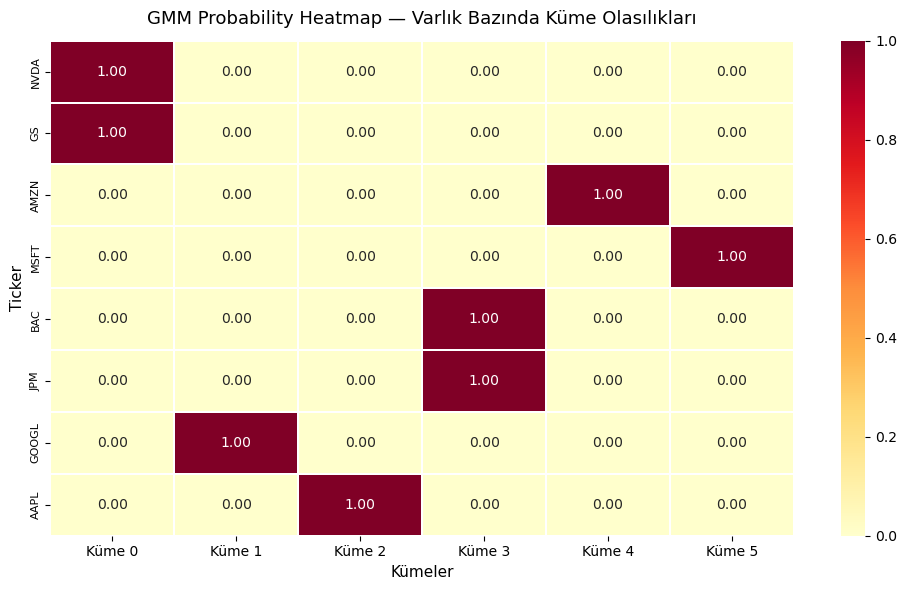

In [21]:
import numpy as np

prob_pd = final_clusters.select(
    "ticker", "prob_array"
).toPandas()

prob_matrix = pd.DataFrame(
    prob_pd["prob_array"].tolist(),
    index=prob_pd["ticker"],
    columns=[f"Küme {i}" for i in range(best_k)]
)

prob_matrix = prob_matrix.sort_values("Küme 0", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(prob_matrix) * 0.4)))
sns.heatmap(
    prob_matrix,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    linecolor="white",
    ax=ax,
    vmin=0,
    vmax=1
)
ax.set_title("GMM Probability Heatmap — Varlık Bazında Küme Olasılıkları", fontsize=13, pad=12)
ax.set_xlabel("Kümeler", fontsize=11)
ax.set_ylabel("Ticker", fontsize=11)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

In [7]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

# Confidence ekle
final_clusters = final_clusters.withColumn(
    "prob_array", vector_to_array("probability")
).withColumn(
    "confidence", F.array_max("prob_array")
)

# Küme bazında istatistikler
cluster_profile = final_clusters.groupBy("prediction").agg(
    F.count("ticker").alias("ticker_sayisi"),
    F.round(F.avg("mean"), 5).alias("ort_getiri"),
    F.round(F.avg("risk"), 5).alias("ort_risk"),
    F.round(F.avg("skewness"), 3).alias("ort_carpiklik"),
    F.round(F.avg("kurtosis"), 3).alias("ort_basiklik"),
    F.round(F.avg("confidence"), 3).alias("ort_guven")
).orderBy("prediction")

print("=== KÜME PROFİLİ ===")
cluster_profile.show(truncate=False)

=== KÜME PROFİLİ ===
+----------+-------------+----------+--------+-------------+------------+---------+
|prediction|ticker_sayisi|ort_getiri|ort_risk|ort_carpiklik|ort_basiklik|ort_guven|
+----------+-------------+----------+--------+-------------+------------+---------+
|0         |2            |0.00147   |0.01915 |-0.275       |1.369       |1.0      |
|1         |1            |0.00341   |0.01667 |1.022        |3.264       |1.0      |
|2         |1            |0.00146   |0.01411 |0.292        |2.333       |1.0      |
|3         |2            |4.0E-4    |0.01379 |-0.621       |1.163       |1.0      |
|4         |1            |1.2E-4    |0.01931 |-0.15        |4.28        |1.0      |
|5         |1            |-8.7E-4   |0.01504 |-2.003       |12.315      |1.0      |
+----------+-------------+----------+--------+-------------+------------+---------+



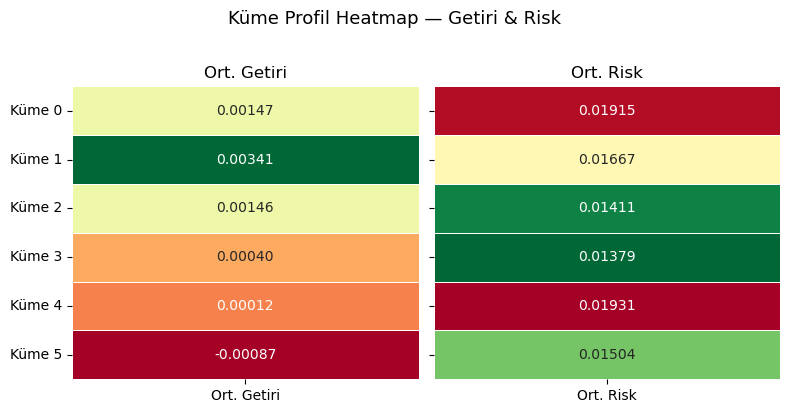

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cluster_pd = final_clusters.groupBy("prediction").agg(
    F.round(F.avg("mean"), 5).alias("ort_getiri"),
    F.round(F.avg("risk"), 5).alias("ort_risk"),
).orderBy("prediction").toPandas()

cluster_pd.index = [f"Küme {i}" for i in cluster_pd["prediction"]]
cluster_pd = cluster_pd.drop(columns=["prediction"])

cluster_normalized = (cluster_pd - cluster_pd.min()) / (cluster_pd.max() - cluster_pd.min())

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

sns.heatmap(
    cluster_normalized[["ort_getiri"]],
    annot=cluster_pd[["ort_getiri"]].values,
    fmt=".5f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Ort. Getiri")
axes[0].set_xticklabels(["Ort. Getiri"])

sns.heatmap(
    cluster_normalized[["ort_risk"]],
    annot=cluster_pd[["ort_risk"]].values,
    fmt=".5f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar=False,
    ax=axes[1]
)
axes[1].set_title("Ort. Risk")
axes[1].set_xticklabels(["Ort. Risk"])

fig.suptitle("Küme Profil Heatmap — Getiri & Risk", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
print("=== KÜME BAZINDA RİSK/GETİRİ SIRALAMASI ===")
final_clusters.withColumn(
    "sharpe_proxy", F.round(F.col("mean") / F.col("risk"), 3)
).select(
    "ticker",
    "prediction",
    F.round("mean", 5).alias("getiri"),
    F.round("risk", 5).alias("risk"),
    F.round("skewness", 3).alias("carpiklik"),
    F.round("kurtosis", 3).alias("basiklik"),
    F.round("confidence", 3).alias("guven"),
    F.col("sharpe_proxy")
).orderBy("prediction", F.col("confidence").desc()) \
 .show(50, truncate=False)

=== KÜME BAZINDA RİSK/GETİRİ SIRALAMASI ===
+------+----------+-------+-------+---------+--------+-----+------------+
|ticker|prediction|getiri |risk   |carpiklik|basiklik|guven|sharpe_proxy|
+------+----------+-------+-------+---------+--------+-----+------------+
|NVDA  |0         |0.00139|0.02119|-0.061   |0.504   |1.0  |0.066       |
|GS    |0         |0.00155|0.0171 |-0.488   |2.234   |1.0  |0.091       |
|GOOGL |1         |0.00341|0.01667|1.022    |3.264   |1.0  |0.204       |
|AAPL  |2         |0.00146|0.01411|0.292    |2.333   |1.0  |0.104       |
|JPM   |3         |3.5E-4 |0.01383|-0.7     |1.146   |1.0  |0.025       |
|BAC   |3         |4.5E-4 |0.01375|-0.542   |1.18    |1.0  |0.033       |
|AMZN  |4         |1.2E-4 |0.01931|-0.15    |4.28    |1.0  |0.006       |
|MSFT  |5         |-8.7E-4|0.01504|-2.003   |12.315  |1.0  |-0.058      |
+------+----------+-------+-------+---------+--------+-----+------------+



In [12]:
print("=== DÜŞÜK GÜVENLİ VARLIKLAR (confidence < 0.70) ===")
final_clusters.filter(F.col("confidence") < 0.70) \
    .select("ticker", "prediction", "confidence") \
    .orderBy("confidence") \
    .show(truncate=False)

=== DÜŞÜK GÜVENLİ VARLIKLAR (confidence < 0.70) ===
+------+----------+----------+
|ticker|prediction|confidence|
+------+----------+----------+
+------+----------+----------+



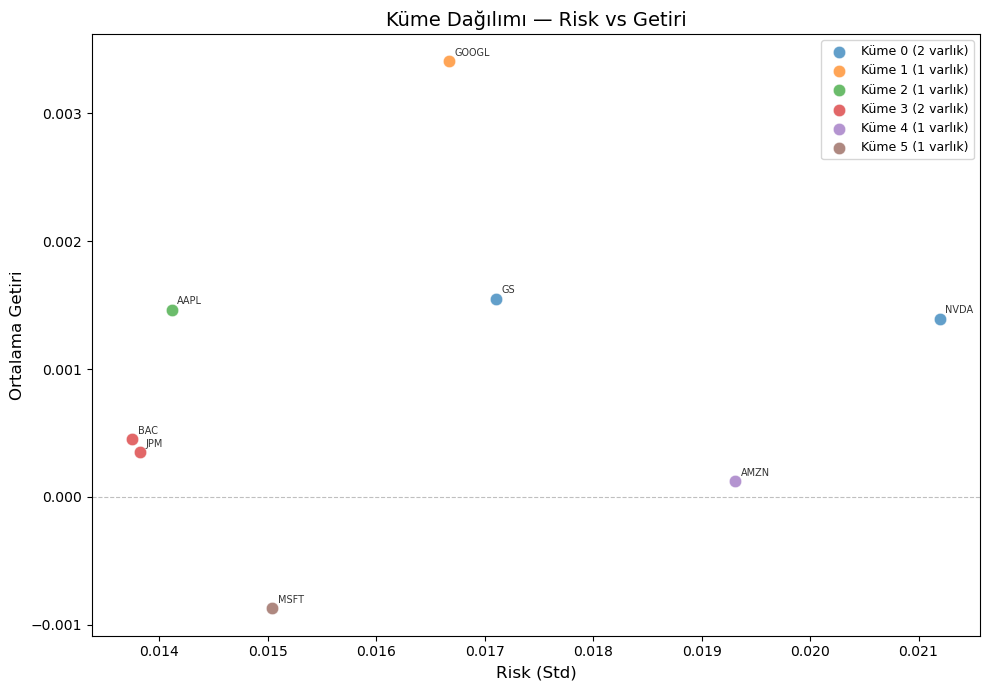

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

scatter_pd = final_clusters.select(
    "ticker", "prediction", "confidence",
    "mean", "risk", "skewness", "kurtosis"
).toPandas()

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab10.colors
clusters = sorted(scatter_pd["prediction"].unique())

for cluster in clusters:
    subset = scatter_pd[scatter_pd["prediction"] == cluster]
    ax.scatter(
        subset["risk"],
        subset["mean"],
        label=f"Küme {cluster} ({len(subset)} varlık)",
        color=colors[cluster],
        alpha=0.7,
        s=80,
        edgecolors="white",
        linewidths=0.5
    )
    # Ticker isimlerini yaz
    for _, row in subset.iterrows():
        ax.annotate(
            row["ticker"],
            (row["risk"], row["mean"]),
            fontsize=7,
            alpha=0.8,
            xytext=(4, 4),
            textcoords="offset points"
        )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)  # Getiri = 0 çizgisi
ax.set_xlabel("Risk (Std)", fontsize=12)
ax.set_ylabel("Ortalama Getiri", fontsize=12)
ax.set_title("Küme Dağılımı — Risk vs Getiri", fontsize=14)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
import pandas as pd
import numpy as np

ROLLING_WINDOW = 90

window = (
    Window
    .partitionBy("ticker")
    .orderBy("date")
    .rowsBetween(-ROLLING_WINDOW + 1, 0)
)

rolling_df = (
    returns_stocks
    .withColumn("vol", F.stddev("return").over(window))
    .withColumn("mom", F.avg("return").over(window))
    .dropna(subset=["vol", "mom"])
)

sdf_ret = rolling_df.groupBy("date").pivot("ticker").agg(F.first("return")).orderBy("date").dropna()
sdf_vol = rolling_df.groupBy("date").pivot("ticker").agg(F.first("vol")).orderBy("date").dropna()
sdf_mom = rolling_df.groupBy("date").pivot("ticker").agg(F.first("mom")).orderBy("date").dropna()

TICKERS = [c for c in sdf_ret.columns if c != "date"]

for c in TICKERS:
    sdf_ret = sdf_ret.withColumnRenamed(c, f"{c}_ret")
    sdf_vol = sdf_vol.withColumnRenamed(c, f"{c}_vol")
    sdf_mom = sdf_mom.withColumnRenamed(c, f"{c}_mom")

sdf_combined = sdf_ret \
    .join(sdf_vol, on="date") \
    .join(sdf_mom, on="date") \
    .dropna()

feature_cols = [c for c in sdf_combined.columns if c != "date"]
print(f"Özellik sayısı: {len(feature_cols)}")
print(f"Satır sayısı  : {sdf_combined.count()}")

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features",
                           withStd=True, withMean=True)

df_vec    = assembler.transform(sdf_combined.drop("date"))
df_scaled = scaler.fit(df_vec).transform(df_vec)

K_max = min(len(feature_cols), sdf_combined.count() - 1)
pca_full  = PCA(k=K_max, inputCol="features", outputCol="pc_scores")
pca_model = pca_full.fit(df_scaled)

explained  = pca_model.explainedVariance.toArray()
cumulative = np.cumsum(explained)

k_80     = np.argmax(cumulative >= 0.80) + 1
k_90     = np.argmax(cumulative >= 0.90) + 1
k_kaiser = int(np.sum(pca_model.explainedVariance.toArray() > 
                      1/len(feature_cols)))  

print("── Optimal K Kriterleri ──")
print(f"%80 varyans için : {k_80} bileşen")
print(f"%90 varyans için : {k_90} bileşen")
print(f"Kaiser kriteri   : {k_kaiser} bileşen")

n = len(explained)
variance_df = pd.DataFrame({
    "bileşen"          : [f"PC{i+1}" for i in range(n)],
    "açıklanan_varyans": explained.round(3),
    "kümülatif"        : cumulative.round(3)
})
print("\n── Açıklanan Varyans ──")
print(variance_df)

Özellik sayısı: 24


26/03/21 11:44:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Satır sayısı  : 1552


[Stage 95:>                                                         (0 + 1) / 1]

── Optimal K Kriterleri ──
%80 varyans için : 5 bileşen
%90 varyans için : 10 bileşen
Kaiser kriteri   : 5 bileşen

── Açıklanan Varyans ──
   bileşen  açıklanan_varyans  kümülatif
0      PC1              0.350      0.350
1      PC2              0.203      0.553
2      PC3              0.130      0.683
3      PC4              0.068      0.751
4      PC5              0.054      0.804
5      PC6              0.032      0.836
6      PC7              0.023      0.859
7      PC8              0.019      0.878
8      PC9              0.018      0.896
9     PC10              0.017      0.912
10    PC11              0.015      0.927
11    PC12              0.014      0.941
12    PC13              0.012      0.953
13    PC14              0.010      0.963
14    PC15              0.008      0.972
15    PC16              0.007      0.978
16    PC17              0.005      0.983
17    PC18              0.004      0.988
18    PC19              0.004      0.991
19    PC20              0.003      0.994

26/03/21 11:44:57 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [5]:
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array
import pandas as pd

K = 6
pca_k = PCA(k=K, inputCol="features", outputCol="pc_scores")
pca_model_k = pca_k.fit(df_scaled)

loadings = pd.DataFrame(
    pca_model_k.pc.toArray(),   
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(K)]
)

print("── Faktör Yükleri ──")
print(loadings.round(3))

print("\n── Her Faktörün En Etkili Değişkenleri ──")
for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False)
    print(f"\n{pc}:")
    for var, _ in top.items():
        print(f"  {var:20s} {loadings.loc[var, pc]:+.3f}")

── Faktör Yükleri ──
             PC1    PC2    PC3    PC4    PC5    PC6
AAPL_ret  -0.014  0.349 -0.085  0.178  0.097 -0.091
AMZN_ret  -0.003  0.319 -0.080  0.295  0.169 -0.033
BAC_ret   -0.027  0.323 -0.130 -0.366 -0.309  0.035
GOOGL_ret -0.024  0.342 -0.090  0.217  0.133 -0.083
GS_ret    -0.020  0.342 -0.141 -0.296 -0.251  0.006
JPM_ret   -0.026  0.324 -0.136 -0.369 -0.303  0.056
MSFT_ret  -0.008  0.358 -0.110  0.241  0.140 -0.008
NVDA_ret  -0.014  0.323 -0.084  0.243  0.166  0.078
AAPL_vol   0.295  0.070  0.115 -0.142  0.180 -0.083
AMZN_vol   0.266  0.001 -0.134 -0.098  0.173  0.067
BAC_vol    0.280  0.099  0.263 -0.093  0.051 -0.121
GOOGL_vol  0.303  0.054  0.052 -0.120  0.183  0.118
GS_vol     0.282  0.092  0.239 -0.090  0.052 -0.164
JPM_vol    0.286  0.091  0.243 -0.093  0.049 -0.212
MSFT_vol   0.322  0.064  0.127 -0.060  0.065 -0.001
NVDA_vol   0.296  0.019 -0.046 -0.043  0.080  0.295
AAPL_mom  -0.154  0.085  0.320  0.014 -0.102 -0.392
AMZN_mom  -0.083  0.125  0.448  0.042 -0.10

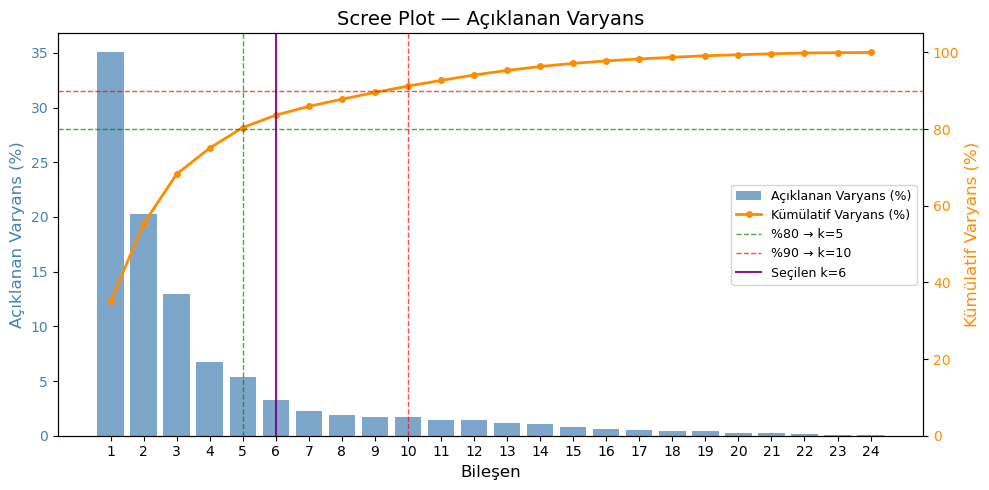

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar — her PC'nin varyansı
ax1.bar(
    range(1, len(explained) + 1),
    explained * 100,
    color="steelblue",
    alpha=0.7,
    label="Açıklanan Varyans (%)"
)
ax1.set_xlabel("Bileşen", fontsize=12)
ax1.set_ylabel("Açıklanan Varyans (%)", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Kümülatif eğri — ikinci eksen
ax2 = ax1.twinx()
ax2.plot(
    range(1, len(cumulative) + 1),
    cumulative * 100,
    color="darkorange",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Kümülatif Varyans (%)"
)
ax2.set_ylabel("Kümülatif Varyans (%)", fontsize=12, color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 105)

# k_80 ve k_90 çizgileri
ax2.axhline(80, color="green", linestyle="--", linewidth=1, alpha=0.7)
ax2.axhline(90, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax2.axvline(k_80, color="green", linestyle="--", linewidth=1, alpha=0.7, label=f"%80 → k={k_80}")
ax2.axvline(k_90, color="red", linestyle="--", linewidth=1, alpha=0.7, label=f"%90 → k={k_90}")

# Seçilen K işareti
ax2.axvline(K, color="purple", linestyle="-", linewidth=1.5, alpha=0.9, label=f"Seçilen k={K}")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)

ax1.set_title("Scree Plot — Açıklanan Varyans", fontsize=14)
ax1.set_xticks(range(1, len(explained) + 1))
plt.tight_layout()
plt.show()

In [8]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms.community import louvain_communities

sdf_wide = (
    returns_stocks
    .groupBy("date")
    .pivot("ticker")
    .agg(F.first("return"))
    .orderBy("date")
    .dropna()
)

TICKERS = [c for c in sdf_wide.columns if c != "date"]

vec = VectorAssembler(inputCols=TICKERS, outputCol="features")
corr_mx = Correlation.corr(vec.transform(sdf_wide.drop("date")), "features")
corr_df = pd.DataFrame(
    corr_mx.collect()[0][0].toArray(),
    index=TICKERS,
    columns=TICKERS
)

THRESHOLD = 0.6

mask = np.triu(np.ones(corr_df.shape), k=1).astype(bool)

corr_filtered = corr_df.where(mask)
corr_filtered = corr_filtered.where(np.abs(corr_filtered) >= THRESHOLD)

edges = (
    corr_filtered
    .stack()
    .reset_index()
    .rename(columns={"level_0": "src", "level_1": "dst", 0: "weight"})
)

G = nx.from_pandas_edgelist(edges, "src", "dst", edge_attr="weight")

communities = louvain_communities(G, weight="weight", seed=42)
community_map = {node: i for i, com in enumerate(communities) for node in com}


metrics = pd.DataFrame({
    "degree"     : dict(G.degree()),
    "betweenness": nx.betweenness_centrality(G, weight="weight"),
    "triangles"  : nx.triangles(G),
    "clustering" : nx.clustering(G),
    "eigenvector": nx.eigenvector_centrality(G, weight="weight", max_iter=1000),
    "pagerank"   : nx.pagerank(G, weight="weight"),
    "community"  : community_map,
})

for col in ["degree", "betweenness", "triangles", "eigenvector", "pagerank"]:
    mx = metrics[col].max()
    metrics[col + "_n"] = metrics[col] / mx if mx > 0 else 0

metrics["risk_score"] = (
    metrics["degree_n"]      * 0.20 +
    metrics["betweenness_n"] * 0.25 +
    metrics["triangles_n"]   * 0.20 +
    metrics["eigenvector_n"] * 0.20 +
    metrics["pagerank_n"]    * 0.15
)

print(
    metrics[
        ["degree", "betweenness", "eigenvector", "community", "risk_score"]
    ]
    .sort_values("risk_score", ascending=False)
    .round(3)
)

       degree  betweenness  eigenvector  community  risk_score
MSFT        4        0.143        0.593          0       1.000
GOOGL       3        0.048        0.516          0       0.715
AAPL        2        0.000        0.412          0       0.414
AMZN        2        0.000        0.403          0       0.410
JPM         2        0.000        0.000          1       0.292
BAC         2        0.000        0.000          1       0.291
GS          2        0.000        0.000          1       0.288
NVDA        1        0.000        0.223          0       0.171


In [9]:
for i in sorted(metrics["community"].unique()):
    hisseler = metrics[metrics["community"] == i].index.tolist()
    print(f"\nCommunity {i} ({len(hisseler)} hisse):")
    print(hisseler)


Community 0 (5 hisse):
['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'NVDA']

Community 1 (3 hisse):
['BAC', 'GS', 'JPM']


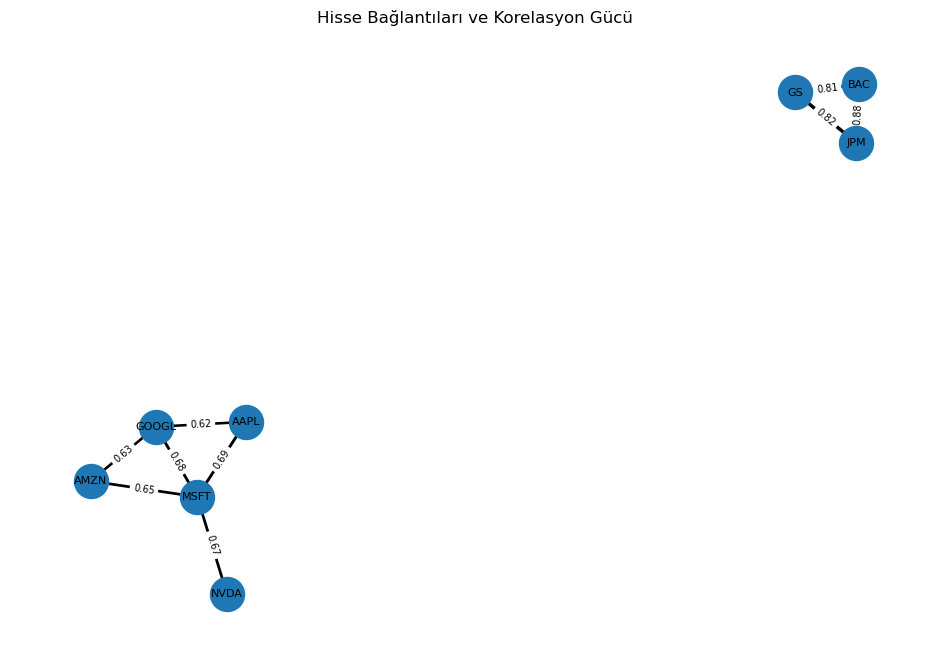

In [21]:
pos     = nx.spring_layout(G, weight="weight", seed=42)
weights = [abs(G[u][v]["weight"]) * 3 for u, v in G.edges()]
labels  = {(u, v): round(d["weight"], 2) for u, v, d in G.edges(data=True)}

plt.figure(figsize=(12, 8))
nx.draw_networkx(G, pos, width=weights, node_size=600, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=7)
plt.title("Hisse Bağlantıları ve Korelasyon Gücü")
plt.axis("off")
plt.show()

In [10]:
edge_list = pd.DataFrame(
    [(u, v, d["weight"]) for u, v, d in G.edges(data=True)],
    columns=["hisse1", "hisse2", "korelasyon"]
).sort_values("korelasyon", ascending=False).reset_index(drop=True)

# Her hissenin metriklerini ekle
edge_list = edge_list.merge(
    metrics[["community", "risk_score", "eigenvector", "betweenness"]],
    left_on="hisse1", right_index=True
).rename(columns={
    "community"  : "community_1",
    "risk_score" : "risk_score_1",
    "eigenvector": "eigenvector_1",
    "betweenness": "betweenness_1"
}).merge(
    metrics[["community", "risk_score", "eigenvector", "betweenness"]],
    left_on="hisse2", right_index=True
).rename(columns={
    "community"  : "community_2",
    "risk_score" : "risk_score_2",
    "eigenvector": "eigenvector_2",
    "betweenness": "betweenness_2"
})

# Aynı community'de mi?
edge_list["ayni_community"] = edge_list["community_1"] == edge_list["community_2"]

print(edge_list.round(3))

  hisse1 hisse2  korelasyon  community_1  risk_score_1  eigenvector_1  \
0    BAC    JPM       0.881            1         0.291          0.000   
1     GS    JPM       0.820            1         0.288          0.000   
2    BAC     GS       0.811            1         0.291          0.000   
3   AAPL   MSFT       0.688            0         0.414          0.412   
4  GOOGL   MSFT       0.680            0         0.715          0.516   
5   MSFT   NVDA       0.665            0         1.000          0.593   
6   MSFT   AMZN       0.654            0         1.000          0.593   
7  GOOGL   AMZN       0.629            0         0.715          0.516   
8   AAPL  GOOGL       0.618            0         0.414          0.412   

   betweenness_1  community_2  risk_score_2  eigenvector_2  betweenness_2  \
0          0.000            1         0.292          0.000          0.000   
1          0.000            1         0.292          0.000          0.000   
2          0.000            1         

In [11]:
paths = []
nodes = list(G.nodes())

for source in nodes:
    for target in nodes:
        if source != target:
            try:
                path = nx.shortest_path(G, source=source, target=target, weight=None)
                paths.append({
                    "kaynak"     : source,
                    "hedef"      : target,
                    "adim_sayisi": len(path) - 1,
                    "yol"        : " → ".join(path)
                })
            except nx.NetworkXNoPath:
                paths.append({
                    "kaynak"     : source,
                    "hedef"      : target,
                    "adim_sayisi": None,
                    "yol"        : "bağlantı yok"
                })

bulasma_df = pd.DataFrame(paths).sort_values(["kaynak", "adim_sayisi"])
print(bulasma_df)

   kaynak  hedef  adim_sayisi                  yol
0    AAPL  GOOGL          1.0         AAPL → GOOGL
1    AAPL   MSFT          1.0          AAPL → MSFT
2    AAPL   AMZN          2.0  AAPL → GOOGL → AMZN
6    AAPL   NVDA          2.0   AAPL → MSFT → NVDA
3    AAPL    BAC          NaN         bağlantı yok
4    AAPL     GS          NaN         bağlantı yok
5    AAPL    JPM          NaN         bağlantı yok
22   AMZN  GOOGL          1.0         AMZN → GOOGL
23   AMZN   MSFT          1.0          AMZN → MSFT
21   AMZN   AAPL          2.0  AMZN → GOOGL → AAPL
27   AMZN   NVDA          2.0   AMZN → MSFT → NVDA
24   AMZN    BAC          NaN         bağlantı yok
25   AMZN     GS          NaN         bağlantı yok
26   AMZN    JPM          NaN         bağlantı yok
32    BAC     GS          1.0             BAC → GS
33    BAC    JPM          1.0            BAC → JPM
28    BAC   AAPL          NaN         bağlantı yok
29    BAC  GOOGL          NaN         bağlantı yok
30    BAC   MSFT          NaN  

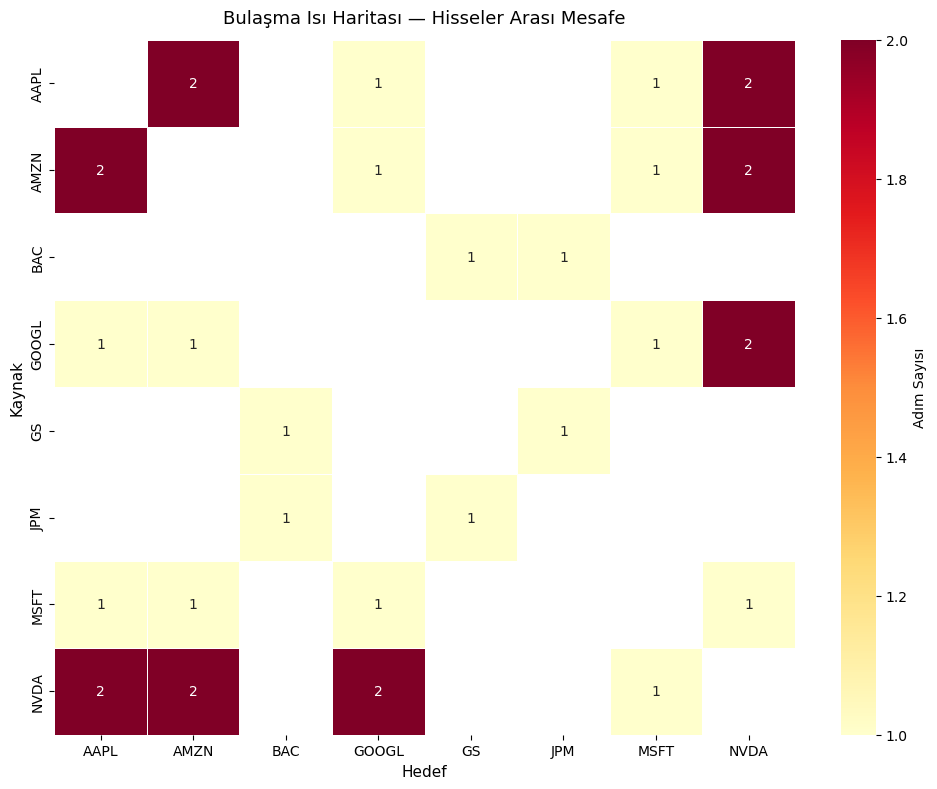

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot: kaynak x hedef → adım sayısı
bulasma_pivot = bulasma_df[bulasma_df["adim_sayisi"].notna()].pivot(
    index="kaynak",
    columns="hedef",
    values="adim_sayisi"
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    bulasma_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Adım Sayısı"}
)
ax.set_title("Bulaşma Isı Haritası — Hisseler Arası Mesafe", fontsize=13, pad=12)
ax.set_xlabel("Hedef", fontsize=11)
ax.set_ylabel("Kaynak", fontsize=11)
plt.tight_layout()
plt.show()

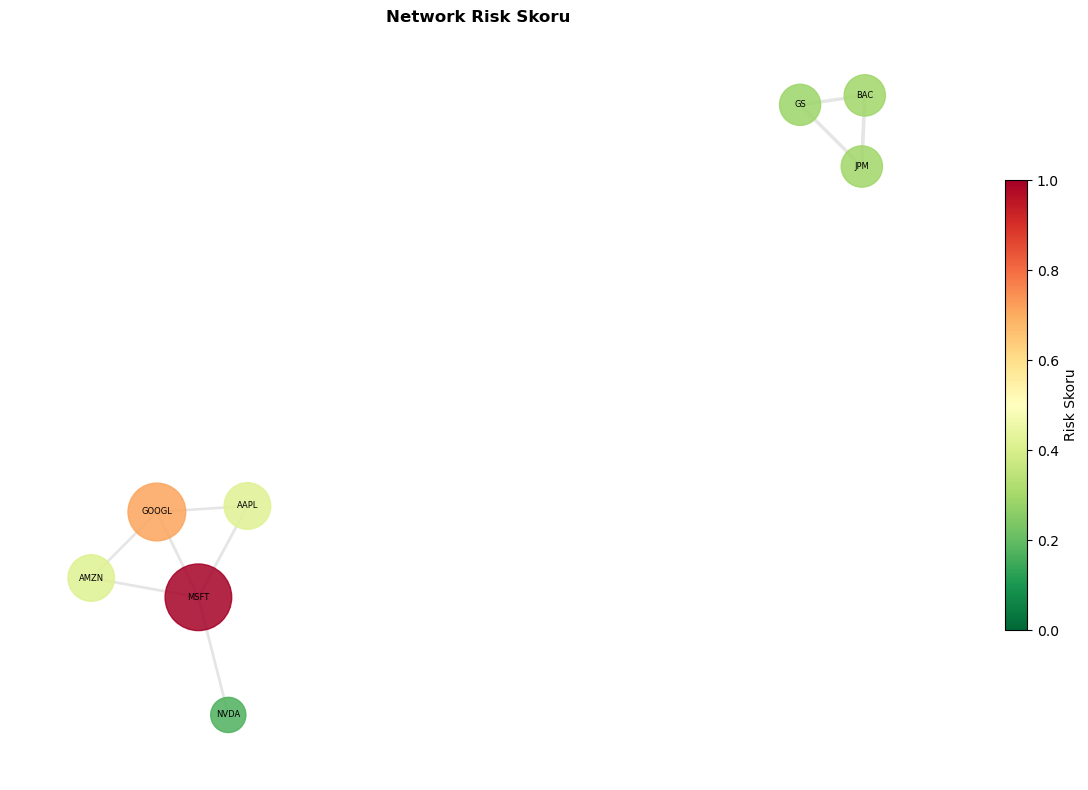

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))

pos     = nx.spring_layout(G, weight="weight", seed=42)
weights = [abs(G[u][v]["weight"]) * 3 for u, v in G.edges()]

risk_vals   = [metrics.loc[n, "risk_score"] for n in G.nodes()]
risk_colors = [plt.cm.RdYlGn_r(v) for v in risk_vals]
risk_sizes  = [300 + metrics.loc[n, "risk_score"] * 2000 for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax, width=weights, alpha=0.2, edge_color="gray")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=risk_colors, node_size=risk_sizes, alpha=0.85)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
ax.set_title("Network Risk Skoru", fontsize=12, fontweight="bold")
ax.axis("off")

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.6, label="Risk Skoru")

plt.tight_layout()
plt.show()

In [25]:
spark.stop()